In [3]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from PIL import Image, ImageDraw, ImageFont
from sklearn.svm import LinearSVC
from matplotlib.colors import LinearSegmentedColormap
from sklearn.calibration import CalibratedClassifierCV
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, cohen_kappa_score, roc_auc_score,
                             classification_report, confusion_matrix)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')


In [4]:
df = pd.read_csv(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\data\map_data.csv")
print(df.head())       # first 5 rows
print(df.columns) 
df.shape

   V001  V002  V003  V021  V023    V005           CASEID  M80  P19  M62  ...  \
0     1    21     2     1     1  156207         1  21  2    1    8  1.0  ...   
1     1    29     2     1     1  156207         1  29  2    1    3  1.0  ...   
2     1   113     3     1     1  156207         1 113  3    1    0  1.0  ...   
3     1   122     2     1     1  156207         1 122  2    1   12  1.0  ...   
4     2     3     2     2     1  141953         2   3  2    1   18  1.0  ...   

   Place_of_delivery  Husbands_education  Maternal_working  \
0                  1                   3                 0   
1                  1                   2                 0   
2                  1                   3                 0   
3                  1                   3                 0   
4                  1                   2                 0   

   Husbands_occupation  Health_insurance  Media_exposure  \
0                    1                 0               1   
1                    1    

(3592, 34)

In [6]:
# ── Select predictor variables from dataframe ─────────────────────────────
features = df[[
    'Age', 'Region', 'Residence', 'Mothers_Education', 'Religion',
     'Wealth_index', 'Birth_order', 'Wanted_pregnancy',
    'Place_of_delivery', 'Husbands_education', 'Maternal_working',
    'Husbands_occupation', 'Health_insurance', 'Media_exposure',
    'Decision_in_healthcare', 'ANC_visit'
]]

# ── Add intercept/constant ────────────────────────────────────────────────
features_const = add_constant(features)

# ── Calculate VIF ─────────────────────────────────────────────────────────
vif_data = pd.DataFrame()

vif_data["Feature"] = features.columns

vif_data["VIF"] = [
    variance_inflation_factor(
        features_const.values,
        i + 1
    )
    for i in range(features.shape[1])
]

# ── Round and sort ────────────────────────────────────────────────────────
vif_data["VIF"] = vif_data["VIF"].round(2)

vif_data = vif_data.sort_values(
    by="VIF",
    ascending=False
)

# ── Save CSV ──────────────────────────────────────────────────────────────
#vif_data.to_csv(  r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\New folder\vif_table.csv", index=False)

# ── Display table ─────────────────────────────────────────────────────────
print(vif_data.to_string(index=False))

               Feature  VIF
          Wealth_index 1.69
     Mothers_Education 1.64
    Husbands_education 1.61
           Birth_order 1.55
                   Age 1.35
     Place_of_delivery 1.25
             ANC_visit 1.24
             Residence 1.21
        Media_exposure 1.17
      Wanted_pregnancy 1.10
Decision_in_healthcare 1.04
      Maternal_working 1.04
              Religion 1.03
                Region 1.03
   Husbands_occupation 1.01
      Health_insurance 1.01


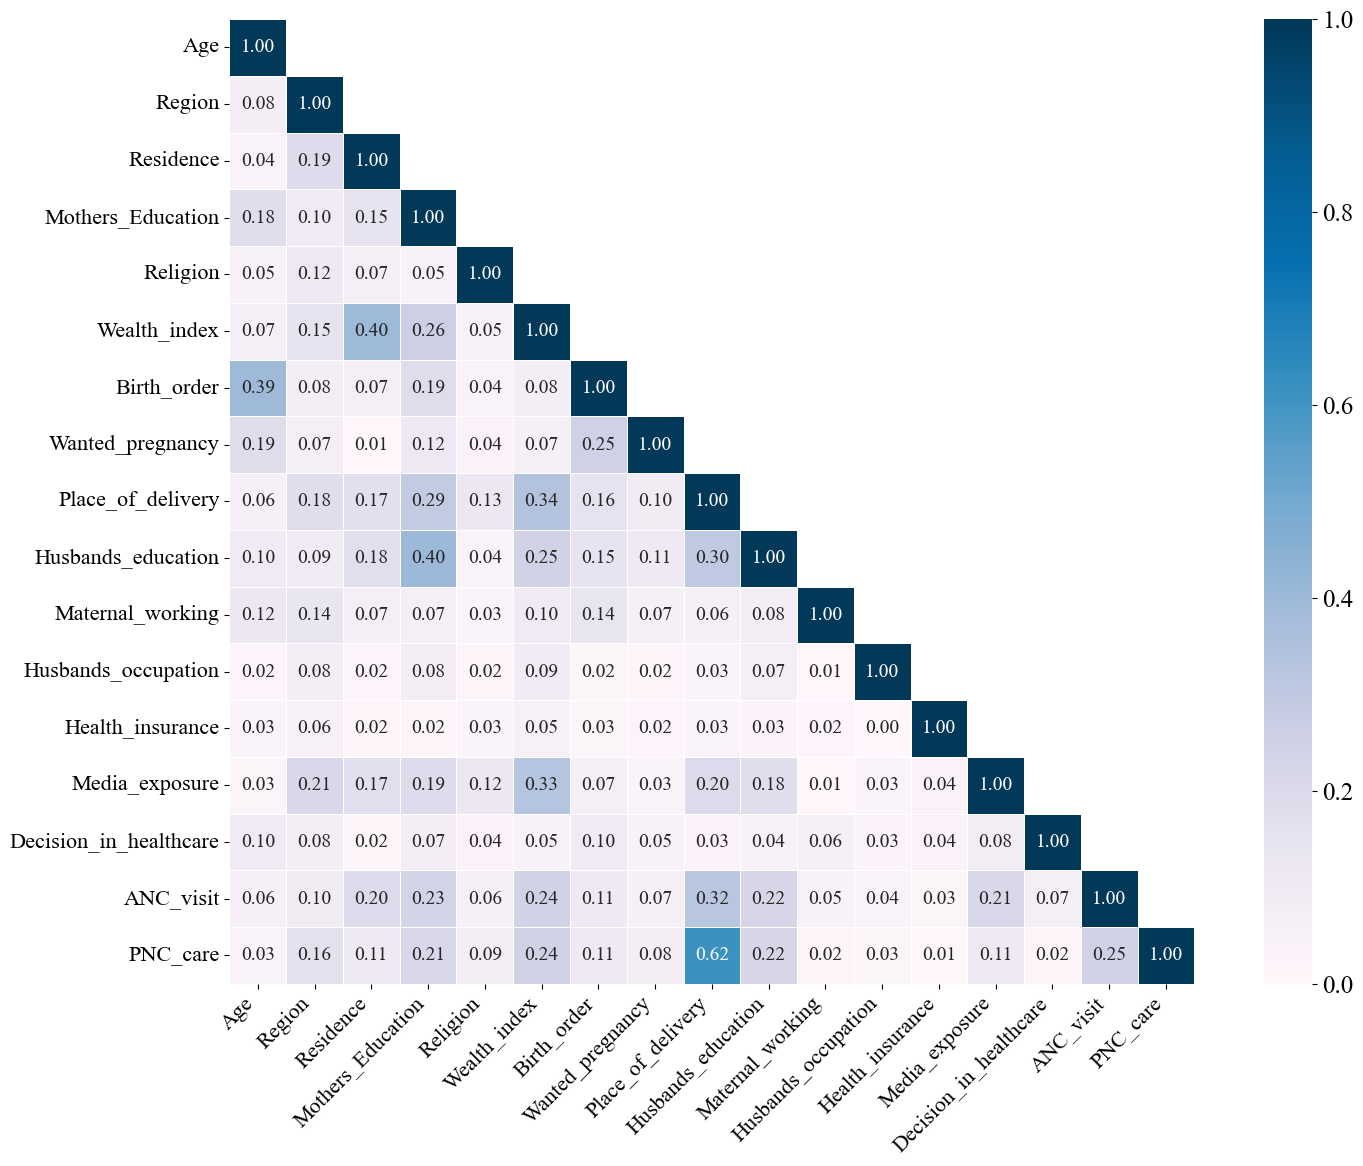

In [35]:
from scipy.stats import chi2_contingency

# Cramér's V function
def cramers_v(x, y):
    if x.name == y.name:          # ← ADD THIS: force diagonal to exactly 1
        return 1.0
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    k = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * k)) if k > 0 else 0.0

# Select relevant columns
cols = [
    'Age', 'Region', 'Residence', 'Mothers_Education', 'Religion',
    'Wealth_index', 'Birth_order', 'Wanted_pregnancy',
    'Place_of_delivery', 'Husbands_education', 'Maternal_working',
    'Husbands_occupation', 'Health_insurance', 'Media_exposure',
    'Decision_in_healthcare', 'ANC_visit', 'PNC_care'
]
df_sub = df[cols]

# Build Cramér's V matrix
n = len(cols)
cramers_matrix = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols)
for col1 in cols:
    for col2 in cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df_sub[col1], df_sub[col2])

# Mask upper triangle
mask = np.triu(np.ones_like(cramers_matrix, dtype=bool), k=1)

# Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    cramers_matrix,
    mask=mask,
    annot=True,
    cmap='PuBu',
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 14},
    vmin=0, vmax=1,
    square=True
)
plt.xticks(rotation=45, ha='right', fontsize=16)
plt.yticks(rotation=0, fontsize=16)
plt.tight_layout()
#plt.savefig(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\New folder\cramer's v heatmap.tiff", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# District-wise PNC utilization
district_pnc = (
    df
    .groupby(['Region', 'ADM2NAME'])['PNC_care']
    .mean()
    .reset_index(name='PNC_percent')
)

# Convert to percentage
district_pnc['PNC_percent'] = (
    district_pnc['PNC_percent'] * 100
)

In [10]:
# ── District-wise PNC utilization (RESPONDENT-WEIGHTED) ───────────────────
# Each district's % reflects the population each woman represents,
# not just a head-count average. Uses the same DHS weight column as your map.

def weighted_pct(group, value_col='PNC_care', weight_col='V005'):
    w = group[weight_col]
    return 100 * np.average(group[value_col], weights=w)

district_pnc = ( df .groupby(['Region', 'ADM2NAME']) .apply(lambda g: weighted_pct(g)).reset_index(name='PNC_percent'))

division_weighted = ( df .groupby('Region').apply(lambda g: weighted_pct(g)) .reset_index(name='Weighted_Mean'))

district_sd = ( district_pnc.groupby('Region')['PNC_percent'] .std().reset_index(name='District_SD'))

mean_sd = division_weighted.merge(district_sd, on='Region')
mean_sd['Mean ± SD'] = (mean_sd['Weighted_Mean'].round(2).astype(str)  + " ± " +
    mean_sd['District_SD'].round(2).astype(str))
mean_sd = mean_sd[['Region', 'Mean ± SD']]
summary_table = (district_pnc
    .groupby('Region') .agg(
        Min    = ('PNC_percent', 'min'),
        Q1     = ('PNC_percent', lambda x: np.percentile(x, 25)),
        Median = ('PNC_percent', 'median'),
        Q3     = ('PNC_percent', lambda x: np.percentile(x, 75)),
        Max    = ('PNC_percent', 'max')
    ) .reset_index())

lowest_district = (district_pnc.loc[district_pnc.groupby('Region')['PNC_percent'].idxmin()]
    [['Region', 'ADM2NAME', 'PNC_percent']].rename(columns={'ADM2NAME': 'Lowest_District', 'PNC_percent': 'Lowest_%'}))

highest_district = (district_pnc.loc[district_pnc.groupby('Region')['PNC_percent'].idxmax()]
    [['Region', 'ADM2NAME', 'PNC_percent']].rename(columns={'ADM2NAME': 'Highest_District', 'PNC_percent': 'Highest_%'}))

final_summary = (summary_table .merge(mean_sd, on='Region')  .merge(lowest_district, on='Region')
    .merge(highest_district, on='Region'))

cols_to_round = ['Min', 'Q1', 'Median', 'Q3', 'Max', 'Lowest_%', 'Highest_%']
final_summary[cols_to_round] = final_summary[cols_to_round].round(2)

final_summary2 = final_summary[['Region', 'Min', 'Q1', 'Median', 'Q3', 'Max', 'Mean ± SD',
    'Lowest_District', 'Lowest_%', 'Highest_District', 'Highest_%']]
print(final_summary2)
#final_summary2.to_csv(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\New folder\summary_statistics_region_pnc2.csv",encoding='utf-8-sig',
#    index=False)
print("✅ Summary statistics table saved!")

   Region    Min     Q1  Median     Q3    Max      Mean ± SD Lowest_District  \
0       1  20.71  46.00   48.57  57.87  68.65  46.85 ± 16.32      Patuakhali   
1       2  38.07  45.20   47.37  58.43  71.33  53.81 ± 10.75       Rangamati   
2       3  35.73  55.15   56.49  61.51  72.63   58.2 ± 10.63       Gopalganj   
3       4  53.18  63.23   73.07  83.39  87.19  73.54 ± 12.32        Bagerhat   
4       5  32.95  42.69   46.63  48.76  53.09    45.04 ± 8.5        Jamalpur   
5       6  40.73  56.37   63.36  73.25  85.61  61.73 ± 15.26       Sirajganj   
6       7  34.98  42.52   50.42  56.09  62.48   51.06 ± 9.73     Lalmonirhat   
7       8  36.87  40.12   43.55  51.28  67.45  46.53 ± 13.58          Sylhet   

   Lowest_% Highest_District  Highest_%  
0     20.71         Pirojpur      68.65  
1     38.07             Feni      71.33  
2     35.73        Madaripur      72.63  
3     53.18          Kushtia      87.19  
4     32.95          Sherpur      53.09  
5     40.73          Naogao

In [12]:
outcome = "PNC_care"

selected_features = [
   "Age","Region","Residence" ,  "Religion", 
  "Mothers_Education",   "Wealth_index",        "Birth_order" ,       
 "Wanted_pregnancy",    "Place_of_delivery" ,  "Husbands_education" ,
 "Husbands_occupation", "ANC_visit", "Media_exposure"]

# Select only needed columns
data = df[selected_features + [outcome]].dropna()

X = data[selected_features]
y = data[outcome].astype(int)

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (2873, 13), Test size: (719, 13)


In [9]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

# Evaluation function
def evaluate_model(model_name, y_test, y_pred, y_prob=None):
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    kappa     = cohen_kappa_score(y_test, y_pred)
    auc       = roc_auc_score(y_test, y_prob) if y_prob is not None else None

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"Kappa     : {kappa:.4f}")
    if auc is not None:
        print(f"AUC       : {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return {
        'Model'    : model_name,
        'Accuracy' : round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall'   : round(recall, 4),
        'F1'       : round(f1, 4),
        'Kappa'    : round(kappa, 4),
        'AUC'      : round(auc, 4) if auc is not None else None
    }

# 10-Fold CV function
def cv_fold_metrics(model_name, estimator, X, y, save_path=None):
    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        estimator.fit(X_tr, y_tr)
        y_pred_val = estimator.predict(X_val)
        y_prob_val = estimator.predict_proba(X_val)[:, 1]

        fold_results.append({
            'Fold'     : f'Fold {fold:02d}',
            'Accuracy' : round(accuracy_score(y_val, y_pred_val), 4),
            'Precision': round(precision_score(y_val, y_pred_val, average='weighted', zero_division=0), 4),
            'Recall'   : round(recall_score(y_val, y_pred_val, average='weighted', zero_division=0), 4),
            'F1'       : round(f1_score(y_val, y_pred_val, average='weighted', zero_division=0), 4),
            'Kappa'    : round(cohen_kappa_score(y_val, y_pred_val), 4),
            'AUC'      : round(roc_auc_score(y_val, y_prob_val), 4)
        })

    df_folds = pd.DataFrame(fold_results)

    avg_row = pd.DataFrame([{
        'Fold'     : 'Average',
        'Accuracy' : round(df_folds['Accuracy'].mean(), 4),
        'Precision': round(df_folds['Precision'].mean(), 4),
        'Recall'   : round(df_folds['Recall'].mean(), 4),
        'F1'       : round(df_folds['F1'].mean(), 4),
        'Kappa'    : round(df_folds['Kappa'].mean(), 4),
        'AUC'      : round(df_folds['AUC'].mean(), 4)
    }])

    std_row = pd.DataFrame([{
        'Fold'     : 'Std Dev',
        'Accuracy' : round(df_folds['Accuracy'].std(), 4),
        'Precision': round(df_folds['Precision'].std(), 4),
        'Recall'   : round(df_folds['Recall'].std(), 4),
        'F1'       : round(df_folds['F1'].std(), 4),
        'Kappa'    : round(df_folds['Kappa'].std(), 4),
        'AUC'      : round(df_folds['AUC'].std(), 4)
    }])

    df_folds = pd.concat([df_folds, avg_row, std_row], ignore_index=True)

    print(f"\n{'='*70}")
    print(f"  Cross-Validation Fold Metrics — {model_name}")
    print(f"{'='*70}")
    print(df_folds.to_string(index=False))

   
    return df_folds

Logistic regression

In [12]:
# Hyperparameter tuning
param_grid_lr = {
    'C'       : [0.01, 0.1, 1, 10, 100],
    'solver'  : ['liblinear', 'lbfgs'],
    'max_iter': [200, 500]
}
lr = GridSearchCV(
    LogisticRegression(random_state=123),
    param_grid_lr, cv=5, scoring='roc_auc', n_jobs=-1
)
lr.fit(X_train, y_train)
best_lr    = lr.best_estimator_
y_pred_lr  = best_lr.predict(X_test)
y_prob_lr  = best_lr.predict_proba(X_test)[:, 1]

print("Best Params   :", lr.best_params_)
print("Best CV Score :", round(lr.best_score_, 4))

# Test set evaluation
test_lr = evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr)

# Save model & predictions

pd.DataFrame({'y_true': y_test, 'y_pred': y_pred_lr, 'y_prob': y_prob_lr
}).to_csv(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\lr\lr_predictions.csv", index=False)
pd.DataFrame([lr.best_params_]).to_csv(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\lr\lr_best_params.csv", index=False)

# 10-Fold CV
fold_lr = cv_fold_metrics(
    "Logistic Regression", best_lr, X_train, y_train)
fold_lr.to_csv(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\lr\lr_cv_metrics.csv")

Best Params   : {'C': 0.01, 'max_iter': 200, 'solver': 'lbfgs'}
Best CV Score : 0.8089

  Logistic Regression
Accuracy  : 0.8052
Precision : 0.8148
Recall    : 0.8052
F1 Score  : 0.8007
Kappa     : 0.5958
AUC       : 0.8014

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.66      0.75       321
           1       0.77      0.92      0.84       403

    accuracy                           0.81       724
   macro avg       0.82      0.79      0.80       724
weighted avg       0.81      0.81      0.80       724

Confusion Matrix:
[[213 108]
 [ 33 370]]

  Cross-Validation Fold Metrics — Logistic Regression
   Fold  Accuracy  Precision  Recall     F1  Kappa    AUC
Fold 01    0.8724     0.8741  0.8724 0.8715 0.7385 0.8791
Fold 02    0.8172     0.8266  0.8172 0.8131 0.6204 0.8104
Fold 03    0.7690     0.7740  0.7690 0.7644 0.5223 0.7773
Fold 04    0.8069     0.8204  0.8069 0.8015 0.5985 0.8118
Fold 05    0.8379     0.8406  0.8379 0.

Random Forest

In [15]:
# Hyperparameter tuning
param_grid_rf = {
    'n_estimators'    : [100, 300, 500],
    'max_depth'       : [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features'    : ['sqrt', 'log2']
}
rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=123),
    param_grid_rf, n_iter=20, cv=5,
    scoring='roc_auc', random_state=123, n_jobs=-1
)
rf.fit(X_train, y_train)
best_rf    = rf.best_estimator_
y_pred_rf  = best_rf.predict(X_test)
y_prob_rf  = best_rf.predict_proba(X_test)[:, 1]

print("Best Params   :", rf.best_params_)
print("Best CV Score :", round(rf.best_score_, 4))

# Test set evaluation
test_rf = evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)

# Save model & predictions
pd.DataFrame({'y_true': y_test, 'y_pred': y_pred_rf, 'y_prob': y_prob_rf
}).to_csv(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\rf\rf_predictions.csv", index=False)
pd.DataFrame([rf.best_params_]).to_csv(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\rf\rf_best_params.csv", index=False)

# 10-Fold CV
fold_rf = cv_fold_metrics(
    "Random Forest", best_rf, X_train, y_train)
fold_rf.to_csv(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\rf\rf_cv_metrics.csv"
)

Best Params   : {'n_estimators': 300, 'min_samples_split': 10, 'max_features': 'log2', 'max_depth': 20}
Best CV Score : 0.8143

  Random Forest
Accuracy  : 0.8080
Precision : 0.8184
Recall    : 0.8080
F1 Score  : 0.8033
Kappa     : 0.6013
AUC       : 0.8055

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.66      0.75       321
           1       0.78      0.92      0.84       403

    accuracy                           0.81       724
   macro avg       0.82      0.79      0.80       724
weighted avg       0.82      0.81      0.80       724

Confusion Matrix:
[[213 108]
 [ 31 372]]

  Cross-Validation Fold Metrics — Random Forest
   Fold  Accuracy  Precision  Recall     F1  Kappa    AUC
Fold 01    0.8724     0.8741  0.8724 0.8715 0.7385 0.8778
Fold 02    0.8172     0.8250  0.8172 0.8135 0.6210 0.8088
Fold 03    0.7690     0.7740  0.7690 0.7644 0.5223 0.7752
Fold 04    0.8034     0.8138  0.8034 0.7987 0.5923 0.8142
Fold 05    

SVM


In [17]:


# Hyperparameter tuning
param_grid_svm = {
    'estimator__C': [0.01, 0.1, 1, 10]
}
svm = GridSearchCV(
    CalibratedClassifierCV(LinearSVC(random_state=123, max_iter=1000)),
    param_grid_svm, cv=5, scoring='roc_auc', n_jobs=-1
)
svm.fit(X_train, y_train)
best_svm   = svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)
y_prob_svm = best_svm.predict_proba(X_test)[:, 1]

print("Best Params   :", svm.best_params_)
print("Best CV Score :", round(svm.best_score_, 4))

# Test set evaluation
test_svm = evaluate_model("SVM", y_test, y_pred_svm, y_prob_svm)

# Save model & predictions

pd.DataFrame({'y_true': y_test, 'y_pred': y_pred_svm, 'y_prob': y_prob_svm
}).to_csv(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\svm\svm_predictions.csv", index=False)
pd.DataFrame([svm.best_params_]).to_csv(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\svm\svm_best_params.csv", index=False)

# 10-Fold CV
fold_svm = cv_fold_metrics(
    "SVM", best_svm, X_train, y_train)
fold_svm.to_csv(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\svm\svm_cv_metrics.csv"
)

Best Params   : {'estimator__C': 10}
Best CV Score : 0.8028

  SVM
Accuracy  : 0.8080
Precision : 0.8184
Recall    : 0.8080
F1 Score  : 0.8033
Kappa     : 0.6013
AUC       : 0.8027

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.66      0.75       321
           1       0.78      0.92      0.84       403

    accuracy                           0.81       724
   macro avg       0.82      0.79      0.80       724
weighted avg       0.82      0.81      0.80       724

Confusion Matrix:
[[213 108]
 [ 31 372]]

  Cross-Validation Fold Metrics — SVM
   Fold  Accuracy  Precision  Recall     F1  Kappa    AUC
Fold 01    0.8724     0.8741  0.8724 0.8715 0.7385 0.8771
Fold 02    0.8207     0.8312  0.8207 0.8164 0.6272 0.8081
Fold 03    0.7724     0.7783  0.7724 0.7677 0.5291 0.7814
Fold 04    0.8069     0.8204  0.8069 0.8015 0.5985 0.7956
Fold 05    0.8379     0.8406  0.8379 0.8363 0.6675 0.8381
Fold 06    0.7897     0.7959  0.7897 0.7

DEcision Tree

In [18]:
# Hyperparameter tuning
param_grid_dt = {
    'max_depth'        : [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 5, 10],
    'criterion'        : ['gini', 'entropy']
}
dt = GridSearchCV(
    DecisionTreeClassifier(random_state=123),
    param_grid_dt, cv=5, scoring='roc_auc', n_jobs=-1
)
dt.fit(X_train, y_train)
best_dt    = dt.best_estimator_
y_pred_dt  = best_dt.predict(X_test)
y_prob_dt  = best_dt.predict_proba(X_test)[:, 1]

print("Best Params   :", dt.best_params_)
print("Best CV Score :", round(dt.best_score_, 4))

# Test set evaluation
test_dt = evaluate_model("Decision Tree", y_test, y_pred_dt, y_prob_dt)

# Save model & predictions
pd.DataFrame({'y_true': y_test, 'y_pred': y_pred_dt, 'y_prob': y_prob_dt
}).to_csv(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\dt\dt_predictions.csv", index=False)
pd.DataFrame([dt.best_params_]).to_csv(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\dt\dt_best_params.csv", index=False)

# 10-Fold CV
fold_dt = cv_fold_metrics(
    "Decision Tree", best_dt, X_train, y_train)
fold_dt.to_csv(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\dt\dt_cv_metrics.csv"
)

Best Params   : {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV Score : 0.8064

  Decision Tree
Accuracy  : 0.7887
Precision : 0.7916
Recall    : 0.7887
F1 Score  : 0.7857
Kappa     : 0.5645
AUC       : 0.8059

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.68      0.74       321
           1       0.77      0.88      0.82       403

    accuracy                           0.79       724
   macro avg       0.79      0.78      0.78       724
weighted avg       0.79      0.79      0.79       724

Confusion Matrix:
[[218 103]
 [ 50 353]]

  Cross-Validation Fold Metrics — Decision Tree
   Fold  Accuracy  Precision  Recall     F1  Kappa    AUC
Fold 01    0.8517     0.8517  0.8517 0.8512 0.6976 0.8730
Fold 02    0.8069     0.8120  0.8069 0.8036 0.6006 0.7969
Fold 03    0.7621     0.7626  0.7621 0.7596 0.5119 0.7584
Fold 04    0.7793     0.7870  0.7793 0.7742 0.5426 0.8098
Fold 05    0

KNN

In [19]:
# Hyperparameter tuning
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan', 'minkowski']
}
knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn, cv=5, scoring='roc_auc', n_jobs=-1
)
knn.fit(X_train, y_train)
best_knn   = knn.best_estimator_
y_pred_knn = best_knn.predict(X_test)
y_prob_knn = best_knn.predict_proba(X_test)[:, 1]

print("Best Params   :", knn.best_params_)
print("Best CV Score :", round(knn.best_score_, 4))

# Test set evaluation
test_knn = evaluate_model("KNN", y_test, y_pred_knn, y_prob_knn)

# Save model & predictions

pd.DataFrame({'y_true': y_test, 'y_pred': y_pred_knn, 'y_prob': y_prob_knn
}).to_csv(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\knn\knn_predictions.csv", index=False)
pd.DataFrame([knn.best_params_]).to_csv(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\knn\knn_best_params.csv", index=False)

# 10-Fold CV
fold_knn = cv_fold_metrics(
    "KNN", best_knn, X_train, y_train)
fold_knn.to_csv(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\knn\knn_cv_metrics.csv"
)

Best Params   : {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'uniform'}
Best CV Score : 0.7965

  KNN
Accuracy  : 0.7707
Precision : 0.7798
Recall    : 0.7707
F1 Score  : 0.7645
Kappa     : 0.5231
AUC       : 0.7972

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.61      0.70       321
           1       0.74      0.90      0.81       403

    accuracy                           0.77       724
   macro avg       0.78      0.75      0.76       724
weighted avg       0.78      0.77      0.76       724

Confusion Matrix:
[[197 124]
 [ 42 361]]

  Cross-Validation Fold Metrics — KNN
   Fold  Accuracy  Precision  Recall     F1  Kappa    AUC
Fold 01    0.8379     0.8405  0.8379 0.8362 0.6667 0.8657
Fold 02    0.7793     0.7853  0.7793 0.7745 0.5420 0.8132
Fold 03    0.7207     0.7257  0.7207 0.7132 0.4197 0.7594
Fold 04    0.7759     0.7856  0.7759 0.7698 0.5344 0.8228
Fold 05    0.8000     0.8038  0.8000 0.7971 0.5881 0.8

XCBoost

In [10]:
# Hyperparameter tuning
param_grid_xgb = {
    'n_estimators'    : [100, 300, 500],
    'max_depth'       : [3, 5, 7],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma'           : [0, 0.1, 0.3]
}
xgb = RandomizedSearchCV(
    XGBClassifier(random_state=123, eval_metric='logloss', use_label_encoder=False),
    param_grid_xgb, n_iter=25, cv=5,
    scoring='roc_auc', random_state=123, n_jobs=-1
)
xgb.fit(X_train, y_train)
best_xgb   = xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("Best Params   :", xgb.best_params_)
print("Best CV Score :", round(xgb.best_score_, 4))

# Test set evaluation
test_xgb = evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb)

# Save model & predictions

#pd.DataFrame({'y_true': y_test, 'y_pred': y_pred_xgb, 'y_prob': y_prob_xgb
#}).to_csv("C:/Users/Raka/OneDrive/Thesis/Raka-Thesis/label encoding/models2/xgb/xgb_predictions.csv", index=False)
#pd.DataFrame([xgb.best_params_]).to_csv("C:/Users/Raka/OneDrive/Thesis/Raka-Thesis/label encoding/models2/xgb/xgb_best_params.csv", index=False)

# 10-Fold CV
fold_xgb = cv_fold_metrics(
    "XGBoost", best_xgb, X_train, y_train)
#fold_xgb.to_csv("C:/Users/Raka/OneDrive/Thesis/Raka-Thesis/label encoding/models2/xgb/xgb_cv_metrics.csv")

Best Params   : {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.7}
Best CV Score : 0.8132

  XGBoost
Accuracy  : 0.8094
Precision : 0.8196
Recall    : 0.8094
F1 Score  : 0.8048
Kappa     : 0.6043
AUC       : 0.8101

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.67      0.76       321
           1       0.78      0.92      0.84       403

    accuracy                           0.81       724
   macro avg       0.83      0.79      0.80       724
weighted avg       0.82      0.81      0.80       724

Confusion Matrix:
[[214 107]
 [ 31 372]]

  Cross-Validation Fold Metrics — XGBoost
   Fold  Accuracy  Precision  Recall     F1  Kappa    AUC
Fold 01    0.8724     0.8741  0.8724 0.8715 0.7385 0.8714
Fold 02    0.8207     0.8312  0.8207 0.8164 0.6272 0.8247
Fold 03    0.7724     0.7783  0.7724 0.7677 0.5291 0.7676
Fold 04    0.8000     0.8128  0.8000 0.7944 0.5842 

Light gbm

In [22]:
# Hyperparameter tuning
param_grid_lgbm = {
    'n_estimators'    : [100, 300, 500],
    'max_depth'       : [-1, 5, 10, 20],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'num_leaves'      : [31, 63, 127],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}
lgbm = RandomizedSearchCV(
    LGBMClassifier(random_state=123, verbose=-1),
    param_grid_lgbm, n_iter=25, cv=5,
    scoring='roc_auc', random_state=123, n_jobs=-1
)
lgbm.fit(X_train, y_train)
best_lgbm   = lgbm.best_estimator_
y_pred_lgbm = best_lgbm.predict(X_test)
y_prob_lgbm = best_lgbm.predict_proba(X_test)[:, 1]

print("Best Params   :", lgbm.best_params_)
print("Best CV Score :", round(lgbm.best_score_, 4))

# Test set evaluation
test_lgbm = evaluate_model("LightGBM", y_test, y_pred_lgbm, y_prob_lgbm)

# Save model & predictions

pd.DataFrame({'y_true': y_test, 'y_pred': y_pred_lgbm, 'y_prob': y_prob_lgbm
}).to_csv("C:/Users/Raka/OneDrive/Thesis/Raka-Thesis/label encoding/models2/lgbm/lgbm_predictions.csv", index=False)
pd.DataFrame([lgbm.best_params_]).to_csv("C:/Users/Raka/OneDrive/Thesis/Raka-Thesis/label encoding/models2/lgbm/lgbm_best_params.csv", index=False)

# 10-Fold CV
fold_lgbm = cv_fold_metrics(
    "LightGBM", best_lgbm, X_train, y_train)
fold_lgbm.to_csv("C:/Users/Raka/OneDrive/Thesis/Raka-Thesis/label encoding/models2/lgbm/lgbm_cv_metrics.csv"
)

Best Params   : {'subsample': 1.0, 'num_leaves': 63, 'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best CV Score : 0.8156

  LightGBM
Accuracy  : 0.8080
Precision : 0.8184
Recall    : 0.8080
F1 Score  : 0.8033
Kappa     : 0.6013
AUC       : 0.8034

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.66      0.75       321
           1       0.78      0.92      0.84       403

    accuracy                           0.81       724
   macro avg       0.82      0.79      0.80       724
weighted avg       0.82      0.81      0.80       724

Confusion Matrix:
[[213 108]
 [ 31 372]]

  Cross-Validation Fold Metrics — LightGBM
   Fold  Accuracy  Precision  Recall     F1  Kappa    AUC
Fold 01    0.8724     0.8741  0.8724 0.8715 0.7385 0.8817
Fold 02    0.8172     0.8284  0.8172 0.8126 0.6197 0.8151
Fold 03    0.7724     0.7783  0.7724 0.7677 0.5291 0.7601
Fold 04    0.8034     0.8156  0.8034 0.7982 

In [23]:
# Test set results
test_results = pd.DataFrame([
    test_lr, test_rf, test_svm,
    test_dt, test_knn, test_xgb, test_lgbm
]).rename(columns={
    'Accuracy':'Test_Accuracy', 'Precision':'Test_Precision',
    'Recall'  :'Test_Recall',   'F1'       :'Test_F1',
    'Kappa'   :'Test_Kappa',    'AUC'      :'Test_AUC'
})

# CV average results
cv_results = pd.DataFrame([
    fold_lr.iloc[-2], fold_rf.iloc[-2], fold_svm.iloc[-2],
    fold_dt.iloc[-2], fold_knn.iloc[-2], fold_xgb.iloc[-2], fold_lgbm.iloc[-2]
])
cv_results['Fold'] = [
    'Logistic Regression', 'Random Forest', 'SVM',
    'Decision Tree', 'KNN', 'XGBoost', 'LightGBM'
]
cv_results = cv_results.rename(columns={
    'Fold'     :'Model',
    'Accuracy' :'CV_Accuracy', 'Precision':'CV_Precision',
    'Recall'   :'CV_Recall',   'F1'       :'CV_F1',
    'Kappa'    :'CV_Kappa',    'AUC'      :'CV_AUC'
})

# Merge & sort
combined_df = pd.merge(test_results, cv_results, on='Model')
combined_df = combined_df[[
    'Model',
    'Test_Accuracy', 'CV_Accuracy',
    'Test_Precision','CV_Precision',
    'Test_Recall',   'CV_Recall',
    'Test_F1',       'CV_F1',
    'Test_Kappa',    'CV_Kappa',
    'Test_AUC',      'CV_AUC'
]].sort_values('CV_AUC', ascending=False).reset_index(drop=True)

combined_df.insert(0, 'Rank', range(1, len(combined_df) + 1))

print("\n" + "="*120)
print("           FINAL MODEL COMPARISON (Test Set vs 10-Fold CV)")
print("="*120)
print(combined_df.to_string(index=False))
print("="*120)

combined_df.to_csv("C:/Users/Raka/OneDrive/Thesis/Raka-Thesis/label encoding/models2/final_model_comparison.csv", index=False)
print("Saved: final_model_comparison.csv")


           FINAL MODEL COMPARISON (Test Set vs 10-Fold CV)
 Rank               Model  Test_Accuracy  CV_Accuracy  Test_Precision  CV_Precision  Test_Recall  CV_Recall  Test_F1  CV_F1  Test_Kappa  CV_Kappa  Test_AUC  CV_AUC
    1       Random Forest         0.8080       0.8056          0.8184        0.8117       0.8080     0.8056   0.8033 0.8019      0.6013    0.5979    0.8055  0.8096
    2 Logistic Regression         0.8052       0.8083          0.8148        0.8157       0.8052     0.8083   0.8007 0.8044      0.5958    0.6032    0.8014  0.8078
    3            LightGBM         0.8080       0.8094          0.8184        0.8175       0.8080     0.8094   0.8033 0.8052      0.6013    0.6050    0.8034  0.8078
    4             XGBoost         0.8094       0.8087          0.8196        0.8166       0.8094     0.8087   0.8048 0.8046      0.6043    0.6036    0.8101  0.8058
    5                 SVM         0.8080       0.8108          0.8184        0.8188       0.8080     0.8108   0.8033 0.8

In [25]:
def get_hyperparams_table():
    rows = [
        {
            'Model'        : 'Logistic Regression',
            'Parameter 1'  : f'C = {best_lr.C}',
            'Parameter 2'  : f'Solver = {best_lr.solver}',
            'Parameter 3'  : f'Max Iter = {best_lr.max_iter}',
            'Parameter 4'  : f'Penalty = {best_lr.penalty}',
            'Parameter 5'  : '-',
            'Parameter 6'  : '-',
        },
        {
            'Model'        : 'Random Forest',
            'Parameter 1'  : f'n_estimators = {best_rf.n_estimators}',
            'Parameter 2'  : f'max_depth = {best_rf.max_depth}',
            'Parameter 3'  : f'max_features = {best_rf.max_features}',
            'Parameter 4'  : f'min_samples_split = {best_rf.min_samples_split}',
            'Parameter 5'  : '-',
            'Parameter 6'  : '-',
        },
        {
            'Model'        : 'SVM',
            'Parameter 1'  : f'C = {best_svm.estimator.C}',
            'Parameter 2'  : 'Kernel = Linear',
            'Parameter 3'  : '-',
            'Parameter 4'  : '-',
            'Parameter 5'  : '-',
            'Parameter 6'  : '-',
        },
        {
            'Model'        : 'Decision Tree',
            'Parameter 1'  : f'max_depth = {best_dt.max_depth}',
            'Parameter 2'  : f'criterion = {best_dt.criterion}',
            'Parameter 3'  : f'min_samples_split = {best_dt.min_samples_split}',
            'Parameter 4'  : f'min_samples_leaf = {best_dt.min_samples_leaf}',
            'Parameter 5'  : '-',
            'Parameter 6'  : '-',
        },
        {
            'Model'        : 'KNN',
            'Parameter 1'  : f'n_neighbors = {best_knn.n_neighbors}',
            'Parameter 2'  : f'weights = {best_knn.weights}',
            'Parameter 3'  : f'metric = {best_knn.metric}',
            'Parameter 4'  : '-',
            'Parameter 5'  : '-',
            'Parameter 6'  : '-',
        },
        {
            'Model'        : 'XGBoost',
            'Parameter 1'  : f'n_estimators = {best_xgb.n_estimators}',
            'Parameter 2'  : f'max_depth = {best_xgb.max_depth}',
            'Parameter 3'  : f'learning_rate = {best_xgb.learning_rate}',
            'Parameter 4'  : f'subsample = {best_xgb.subsample}',
            'Parameter 5'  : f'colsample_bytree = {best_xgb.colsample_bytree}',
            'Parameter 6'  : f'gamma = {best_xgb.gamma}',
        },
        {
            'Model'        : 'LightGBM',
            'Parameter 1'  : f'n_estimators = {best_lgbm.n_estimators}',
            'Parameter 2'  : f'max_depth = {best_lgbm.max_depth}',
            'Parameter 3'  : f'learning_rate = {best_lgbm.learning_rate}',
            'Parameter 4'  : f'num_leaves = {best_lgbm.num_leaves}',
            'Parameter 5'  : f'subsample = {best_lgbm.subsample}',
            'Parameter 6'  : f'colsample_bytree = {best_lgbm.colsample_bytree}',
        },
    ]
    return pd.DataFrame(rows)

hp_df = get_hyperparams_table()

print("\n" + "="*80)
print("         HYPERPARAMETER CONFIGURATIONS")
print("="*80)
print(hp_df.to_string(index=False))
print("="*80)

# Save
hp_df.to_csv("C:/Users/Raka/OneDrive/Thesis/Raka-Thesis/label encoding/models2/hyperparameter_configurations.csv", index=False)
print("Saved: hyperparameter_configurations.csv")


         HYPERPARAMETER CONFIGURATIONS
              Model        Parameter 1       Parameter 2           Parameter 3            Parameter 4            Parameter 5            Parameter 6
Logistic Regression           C = 0.01    Solver = lbfgs        Max Iter = 200           Penalty = l2                      -                      -
      Random Forest n_estimators = 300    max_depth = 20   max_features = log2 min_samples_split = 10                      -                      -
                SVM             C = 10   Kernel = Linear                     -                      -                      -                      -
      Decision Tree     max_depth = 10  criterion = gini min_samples_split = 2  min_samples_leaf = 10                      -                      -
                KNN   n_neighbors = 21 weights = uniform    metric = manhattan                      -                      -                      -
            XGBoost n_estimators = 100     max_depth = 5  learning_rate 

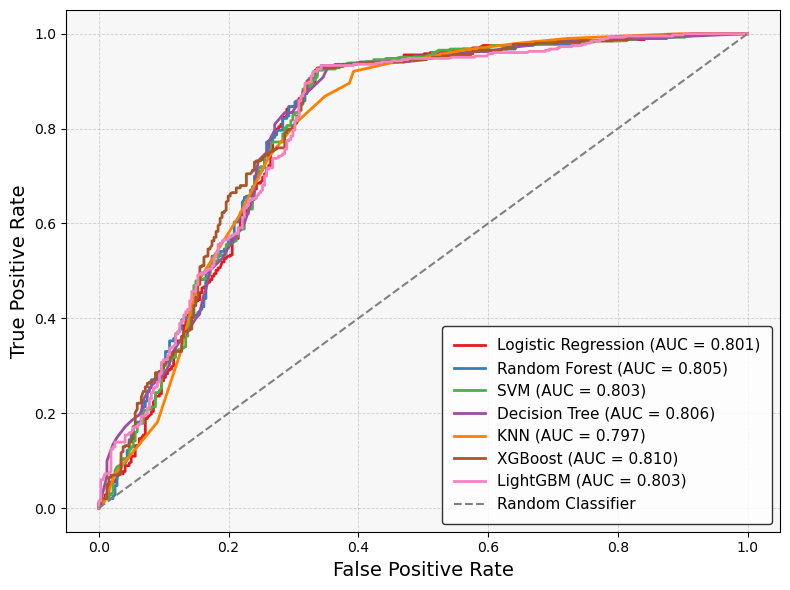

In [31]:

# Model predictions
models = [
    ("Logistic Regression", y_prob_lr),
    ("Random Forest",       y_prob_rf),
    ("SVM",                 y_prob_svm),
    ("Decision Tree",       y_prob_dt),
    ("KNN",                 y_prob_knn),
    ("XGBoost",             y_prob_xgb),
    ("LightGBM",            y_prob_lgbm),
]

# Colors for each model
colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3",
          "#ff7f00", "#a65628", "#f781bf"]

# Figure
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_facecolor("#f7f7f7")
fig.patch.set_facecolor("#ffffff")

for (name, y_prob), color in zip(models, colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2,
            label=f"{name} (AUC = {roc_auc:.3f})",
            color=color)

# Diagonal reference line
ax.plot([0, 1], [0, 1],
        linestyle="--", linewidth=1.5,
        color="gray", label="Random Classifier")

# Labels & formatting
ax.set_xlabel("False Positive Rate", fontsize=14)
ax.set_ylabel("True Positive Rate",  fontsize=14)
#ax.set_title("AUROC Curve Comparison — All Models",fontfamily="Times New Roman",fontsize=13, fontweight="bold", pad=14)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.legend(
    loc="lower right", fontsize=11,
    frameon=True, facecolor="white",
    edgecolor="black", borderpad=0.8
)

plt.tight_layout()
plt.savefig("C:/Users/Raka/OneDrive/Thesis/Raka-Thesis/label encoding/models2//all_models_auroc_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

##"Global Feature Importance — XGBoost"

#### XGB SHAP

In [32]:
# SHAP for XGBoost
explainer_xgb   = shap.TreeExplainer(best_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test)


# Save raw SHAP values
shap_xgb_df = pd.DataFrame(shap_values_xgb, columns=X_test.columns.tolist())
#shap_xgb_df.to_csv(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\New folder\xgb\xgb_shap_values.csv", index=False)
print("XGBoost SHAP values saved.")

XGBoost SHAP values saved.


In [36]:
shap_xgb_df['Division'] = X_test['Region'].values
shap_xgb_df['District'] = df.loc[X_test.index, 'ADM2NAME'].values


# DIVISION-WISE MEAN ABSOLUTE SHAP VALUES

# Select feature columns only
feature_cols = X_test.columns.tolist()

# Calculate mean absolute SHAP by division
division_shap = (
    shap_xgb_df
    .groupby('Division')[feature_cols]
    .apply(lambda x: np.abs(x).mean())
    .reset_index()
)

# # Save division-wise SHAP
# division_shap.to_csv(
#     r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\New folder\xgb\division_wise_shap_value_xgb.csv",
#     index=False
# )

print("✅ Division-wise SHAP values saved!")


# DISTRICT-WISE MEAN ABSOLUTE SHAP VALUES

district_shap = (
    shap_xgb_df
    .groupby('District')[feature_cols]
    .apply(lambda x: np.abs(x).mean())
    .reset_index()
)

# # Save district-wise SHAP
# district_shap.to_csv(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\New folder\xgb\district_wise_shap_value_xgb.csv",
#     index=False)

print("✅ District-wise SHAP values saved!")



division_district_shap = (
    shap_xgb_df
    .groupby(['Division', 'District'])[feature_cols]
    .apply(lambda x: np.abs(x).mean())
    .reset_index()
)

# division_district_shap.to_csv( r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\New folder\xgb\division_district_wise_shap_value_xgb.csv",
#     index=False)

print("✅ Division + district-wise SHAP values saved!")



✅ Division-wise SHAP values saved!
✅ District-wise SHAP values saved!
✅ Division + district-wise SHAP values saved!


In [19]:
# XGBoost SHAP importance
shap_df_xgb = pd.DataFrame({
    'Feature'        : X_test.columns.tolist(),
    'Mean_SHAP_Value': np.abs(shap_values_xgb).mean(axis=0)
}).sort_values('Mean_SHAP_Value', ascending=False).reset_index(drop=True)
shap_df_xgb.insert(0, 'Rank', range(1, len(shap_df_xgb) + 1))

print("\n" + "="*45)
print("   SHAP Feature Importance — XGBoost")
print("="*45)
print(shap_df_xgb.to_string(index=False))
#shap_df_xgb.to_csv(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\New folder\xgb\xgb_shap_importance.csv", index=False)


   SHAP Feature Importance — XGBoost
 Rank             Feature  Mean_SHAP_Value
    1   Place_of_delivery         1.286420
    2           ANC_visit         0.196203
    3              Region         0.108532
    4        Wealth_index         0.092353
    5  Husbands_education         0.082955
    6   Mothers_Education         0.070683
    7      Media_exposure         0.068177
    8    Wanted_pregnancy         0.050343
    9           Residence         0.040419
   10                 Age         0.036187
   11 Husbands_occupation         0.029654
   12         Birth_order         0.026315
   13            Religion         0.011256


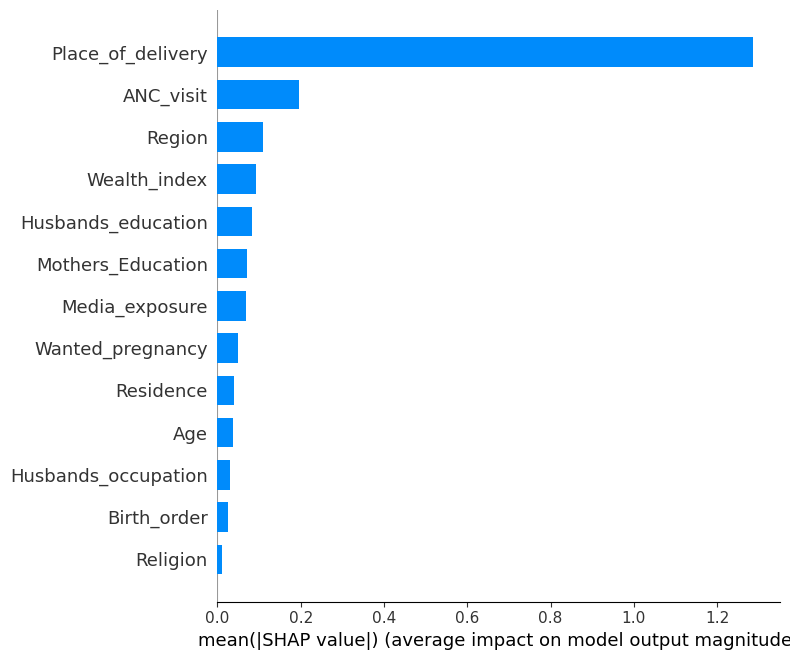

In [17]:
plt.figure(figsize=(6, 4))
shap.summary_plot(
    shap_values_xgb,
    X_test,
    plot_type="bar",
    feature_names=X_test.columns.tolist(),
    show=False
)
#plt.title("Global Feature Importance — XGBoost",fontfamily="Times New Roman",fontsize=13, fontweight="bold")
plt.tight_layout()
# plt.savefig(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\New folder\xgb\xgb_shap_bar.tiff", dpi=300, bbox_inches="tight")
plt.show()

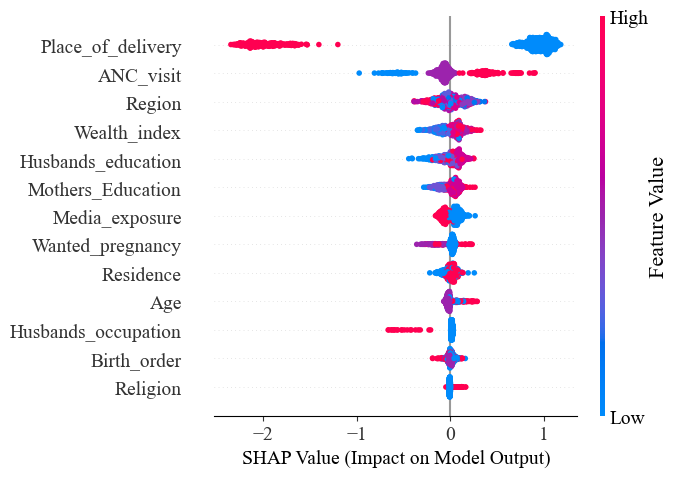

XGBoost SHAP beeswarm saved.


In [18]:


mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size']   = 14

fig, ax = plt.subplots(figsize=(7, 5))
shap.summary_plot(
    shap_values_xgb,
    X_test,
    plot_type="dot",
    show=False,
    color_bar=True,
    plot_size=None
)

ax = plt.gca()
ax.set_xlabel(
    "SHAP Value (Impact on Model Output)",
    fontfamily="Times New Roman", fontsize=14
)
ax.tick_params(labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontfamily("Times New Roman")

cb = plt.gcf().axes[-1]
cb.tick_params(labelsize=14)
cb.set_ylabel("Feature Value",
              fontfamily="Times New Roman", fontsize=16)

plt.tight_layout()
# plt.savefig(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\New folder\xgb\xgb_shap_beesworm.tiff", dpi=300, bbox_inches="tight")
plt.show()
print("XGBoost SHAP beeswarm saved.")

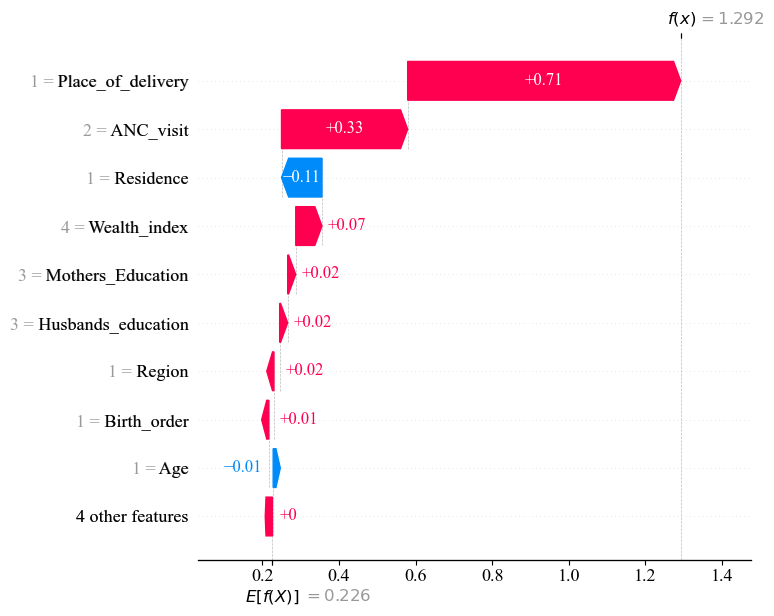

XGBoost SHAP waterfall saved.


In [34]:
# Waterfall plot
idx        = 8
shap_exp_xgb = shap.Explanation(
    values        = shap_values_xgb[idx],
    base_values   = explainer_xgb.expected_value,
    data          = X_test.iloc[idx],
    feature_names = X_test.columns.tolist()
)

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size']   = 18

plt.figure(figsize=(7, 4))
shap.plots.waterfall(shap_exp_xgb, show=False)
plt.tight_layout()
# plt.savefig(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\New folder\xgb\xgb_shap_waterfall.tiff", dpi=300, bbox_inches="tight")
plt.show()
print("XGBoost SHAP waterfall saved.")

Top 10 features: ['Place_of_delivery', 'ANC_visit', 'Region', 'Wealth_index', 'Husbands_education', 'Mothers_Education', 'Media_exposure', 'Wanted_pregnancy', 'Residence', 'Age']

Interaction map:
Place_of_delivery         → colored by ANC_visit
ANC_visit                 → colored by Region
Region                    → colored by Wealth_index
Wealth_index              → colored by Husbands_education
Husbands_education        → colored by Mothers_Education
Mothers_Education         → colored by Media_exposure
Media_exposure            → colored by Wanted_pregnancy
Wanted_pregnancy          → colored by Residence
Residence                 → colored by Age
Age                       → colored by Place_of_delivery


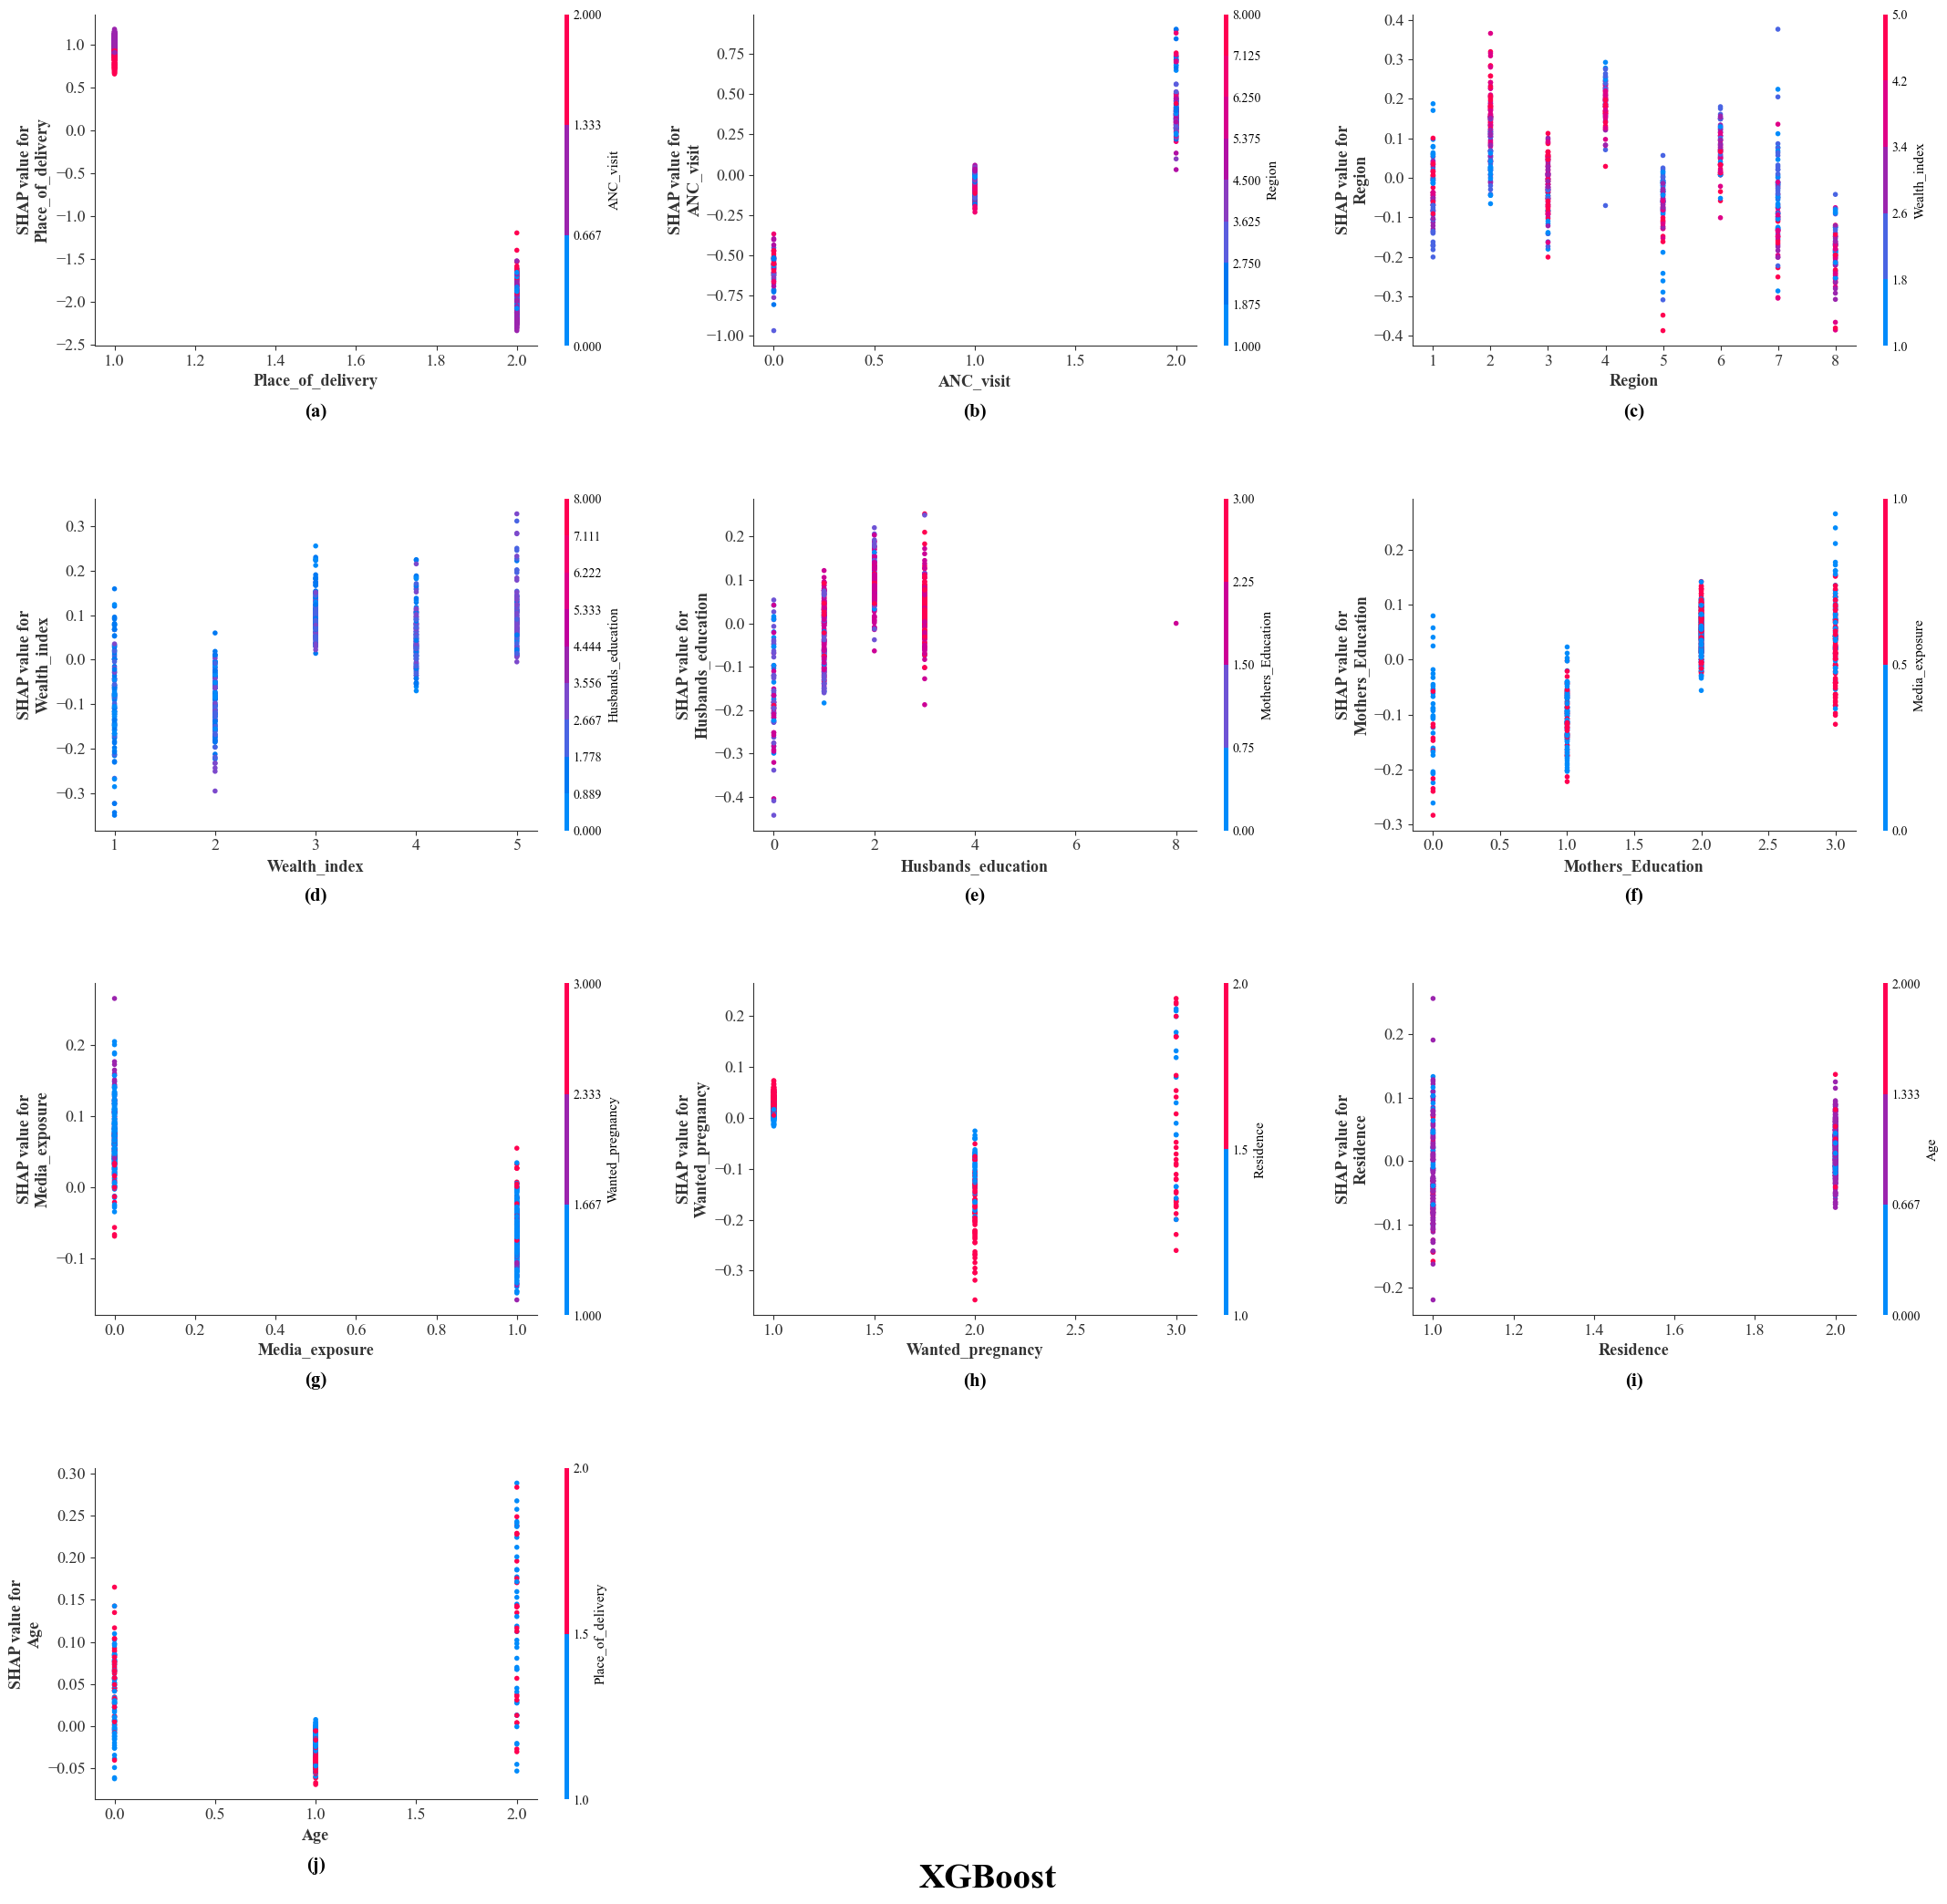

✅ Top 10 SHAP dependence plot saved!


In [37]:

top_features = shap_df_xgb['Feature'].tolist()[:10]
print("Top 10 features:", top_features)


interaction_map = {}

for i, feat in enumerate(top_features):
    # choose next feature cyclically for color interaction
    interaction_map[feat] = top_features[(i + 1) % len(top_features)]

print("\nInteraction map:")
for k, v in interaction_map.items():
    print(f"{k:25s} → colored by {v}")


fig, axes = plt.subplots(4, 3, figsize=(22, 22))
fig.patch.set_facecolor("#ffffff")

axes = axes.flatten()

labels = [
    '(a)', '(b)', '(c)', '(d)', '(e)',
    '(f)', '(g)', '(h)', '(i)', '(j)'
]


for i, feature in enumerate(top_features):

    plt.sca(axes[i])

    shap.dependence_plot(
        feature,
        shap_values_xgb,
        X_test,
        feature_names     = X_test.columns.tolist(),
        interaction_index = interaction_map[feature],
        ax   = axes[i],
        show = False
    )

   
    axes[i].tick_params(axis='both', labelsize=13)

    axes[i].set_xlabel(
        axes[i].get_xlabel(),
        fontsize=13,
        fontfamily="Times New Roman",
        fontweight="bold"
    )

    axes[i].set_ylabel(
        axes[i].get_ylabel(),
        fontsize=13,
        fontfamily="Times New Roman",
        fontweight="bold"
    )

    axes[i].spines[['top', 'right']].set_visible(False)

   
    axes[i].text(
        0.5, -0.20,
        labels[i],
        transform = axes[i].transAxes,
        ha='center',
        va='center',
        fontsize=15,
        fontweight='bold',
        fontfamily="Times New Roman"
    )


for j in range(len(top_features), len(axes)):
    fig.delaxes(axes[j])


for ax_child in fig.axes:
    if ax_child not in axes:
        try:
            ax_child.yaxis.label.set_fontsize(11)
            ax_child.yaxis.label.set_fontfamily("Times New Roman")
            ax_child.tick_params(labelsize=10)
        except:
            pass


plt.tight_layout(h_pad=3.5, w_pad=1.5)

plt.subplots_adjust(
    bottom = 0.06,
    top    = 0.95
)


fig.text(
    0.5, 0.02,
    "XGBoost",
    ha='center',
    va='center',
    fontsize=28,
    fontweight='bold',
    fontfamily="Times New Roman"
)


#plt.savefig(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\New folder\xgb\xgb_shap_dependence_top10.tiff", dpi=600,  bbox_inches="tight")

plt.show()

print("✅ Top 10 SHAP dependence plot saved!")

<Figure size 700x500 with 0 Axes>

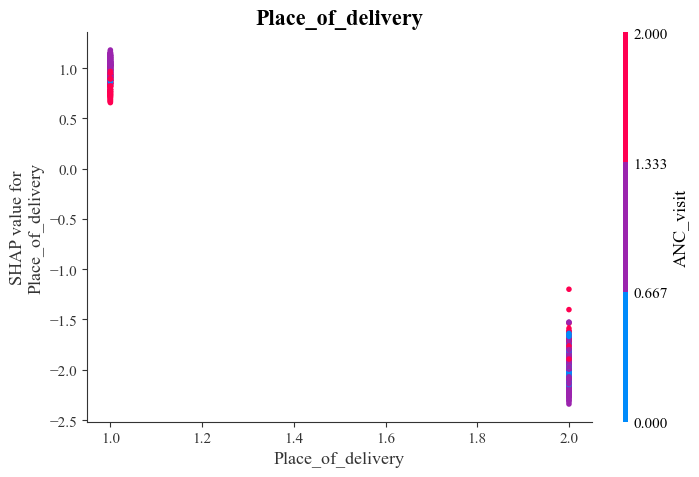

<Figure size 700x500 with 0 Axes>

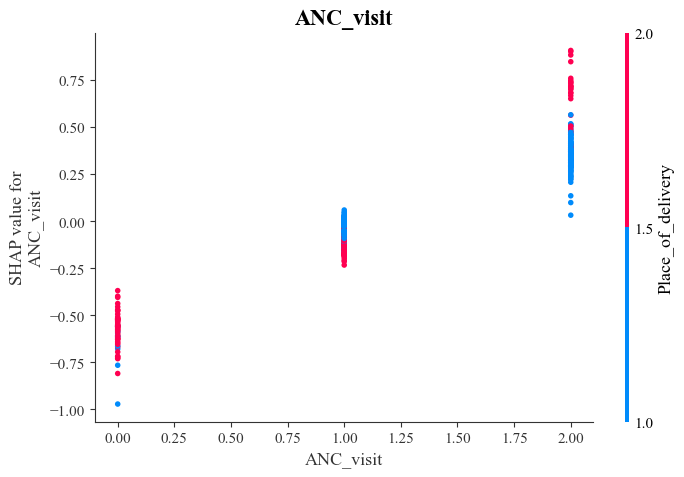

<Figure size 700x500 with 0 Axes>

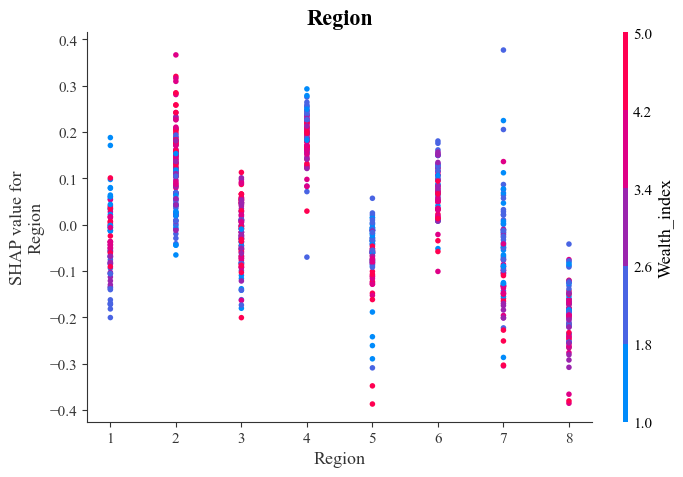

<Figure size 700x500 with 0 Axes>

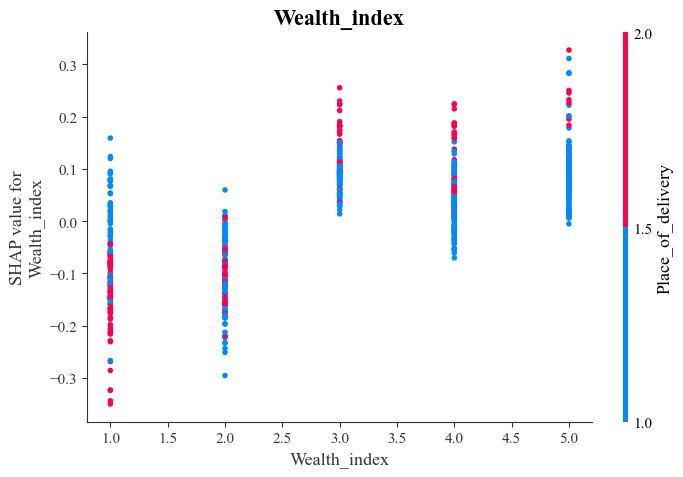

<Figure size 700x500 with 0 Axes>

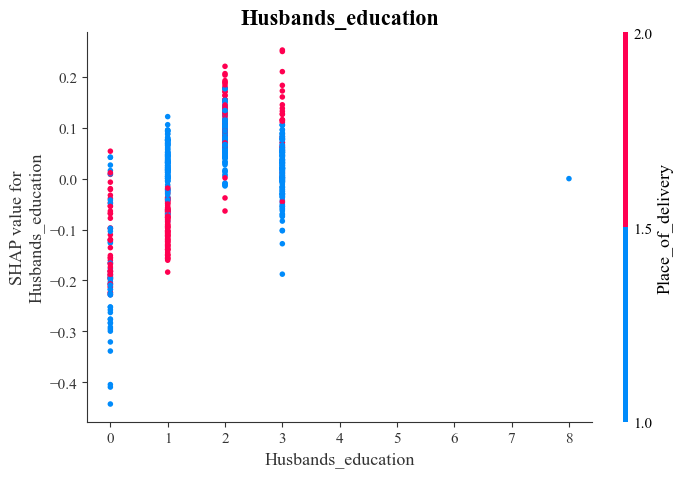

<Figure size 700x500 with 0 Axes>

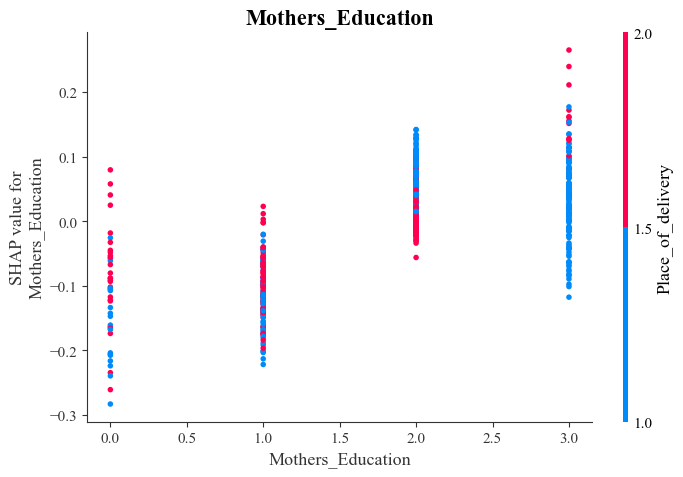

<Figure size 700x500 with 0 Axes>

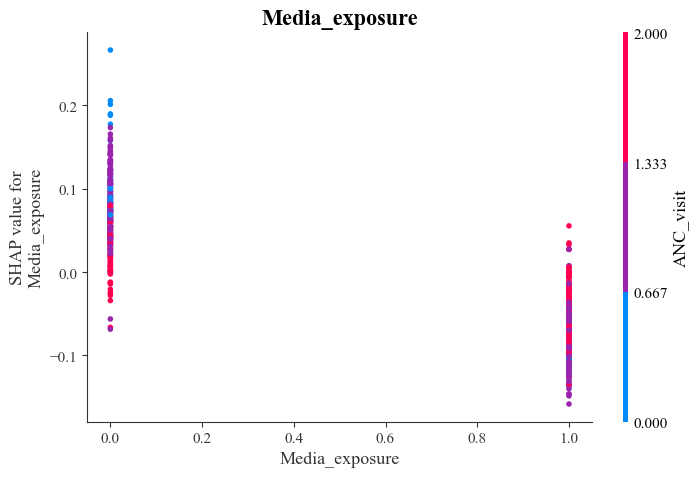

<Figure size 700x500 with 0 Axes>

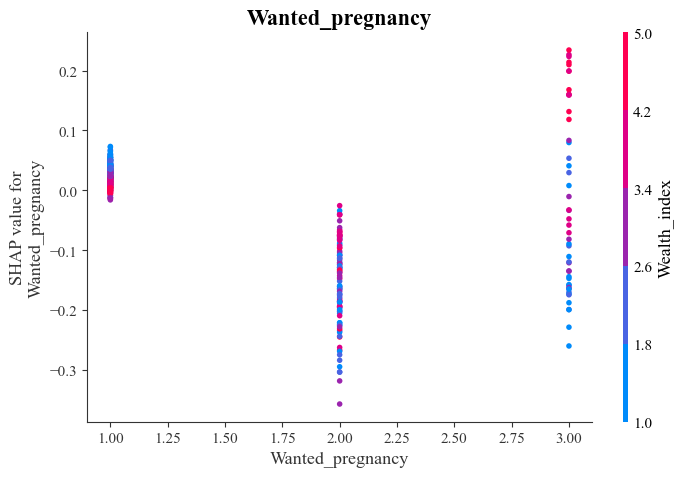

<Figure size 700x500 with 0 Axes>

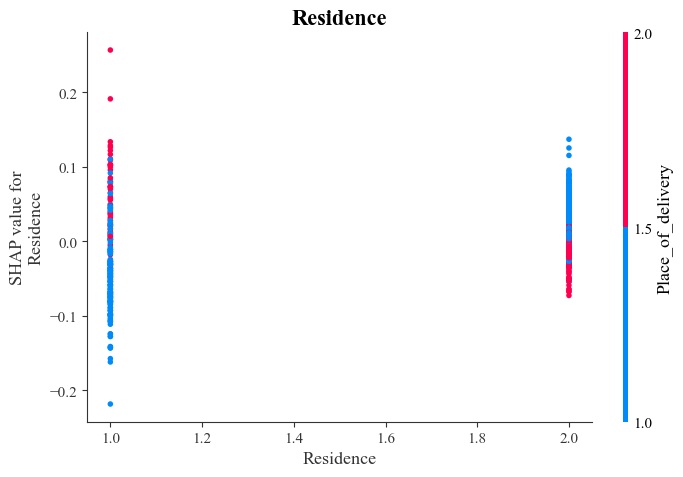

<Figure size 700x500 with 0 Axes>

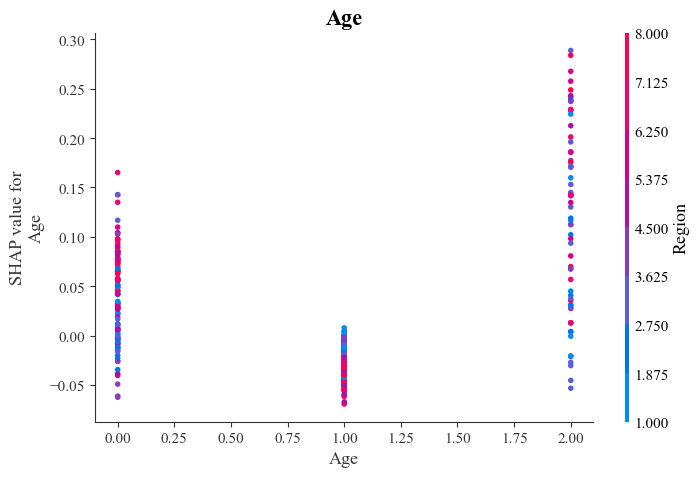

In [23]:
# Most important feature vs second most important
top_features = shap_df_xgb['Feature'].tolist()  # ranked by importance

for feature in top_features[:10]:                 # top 3 features
    plt.figure(figsize=(7, 5))
    shap.dependence_plot(
        feature,
        shap_values_xgb,
        X_test,
        feature_names=X_test.columns.tolist(),
        show=False
    )
    plt.title(f"{feature}",
              fontfamily="Times New Roman",
              fontsize=16, fontweight="bold")
    plt.tight_layout()
    # plt.savefig(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\New folder\xgb\xgb_shap_dependence_{feature}.tiff", dpi=600, bbox_inches="tight") 
    plt.show()

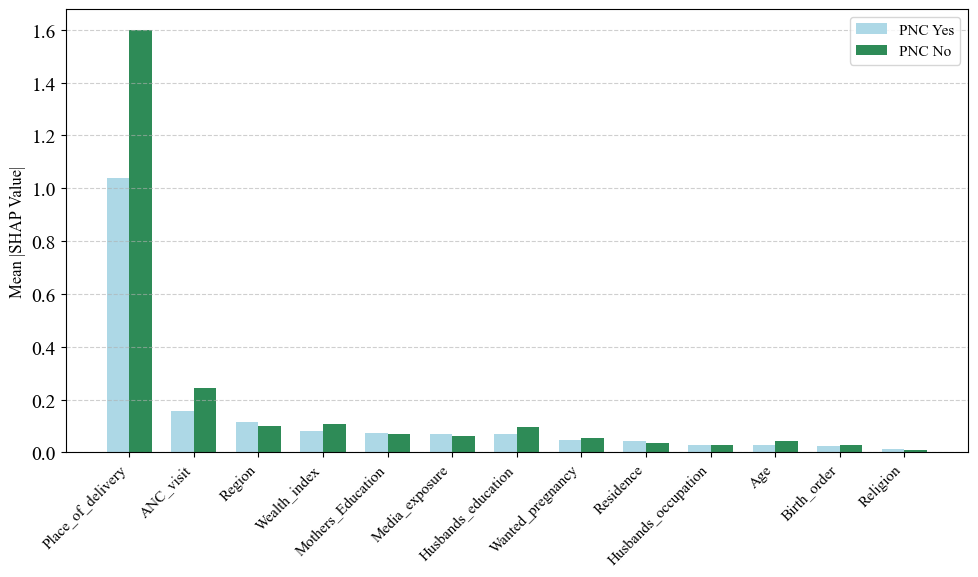

In [24]:
# Split test set by outcome
pnc_yes_idx = np.where(y_test.values == 1)[0]
pnc_no_idx  = np.where(y_test.values == 0)[0]

shap_yes = shap_values_xgb[pnc_yes_idx]
shap_no  = shap_values_xgb[pnc_no_idx]

# Mean SHAP per group
group_df = pd.DataFrame({
    'Feature'     : X_test.columns.tolist(),
    'PNC Yes SHAP': np.abs(shap_yes).mean(axis=0),
    'PNC No SHAP' : np.abs(shap_no).mean(axis=0)
}).sort_values('PNC Yes SHAP', ascending=False)

# Plot
x     = np.arange(len(group_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, group_df['PNC Yes SHAP'],
       width, label='PNC Yes', color='lightblue')
ax.bar(x + width/2, group_df['PNC No SHAP'],
       width, label='PNC No',  color='seagreen')

ax.set_xticks(x)
ax.set_xticklabels(group_df['Feature'],
                   rotation=45, ha='right',
                   fontfamily="Times New Roman", fontsize=11)
ax.set_ylabel("Mean |SHAP Value|",
              fontfamily="Times New Roman", fontsize=12)
#ax.set_title("Feature Importance by PNC Outcome — XGBoost",fontfamily="Times New Roman",fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
# plt.savefig(r"C:\Users\Raka\OneDrive\Thesis\Raka-Thesis\label encoding\models2\New folder\xgb\xgb_shap_group_comparison.png",  dpi=300, bbox_inches="tight")
plt.show()